# 02 — Preprocessing, Feature Engineering, and Paper-Grounded Pseudo Labeling

Notebook ini membuat dataset modeling dari output Notebook 01. Flood tetap supervised regression menggunakan target asli `FloodProbability`. Rice supply chain dibuat menjadi pseudo-label vulnerability karena tidak ada target asli pada dataset.

Perubahan metodologis penting:

- **Label utama dibuat dari rule-based scoring berbasis literatur domain**, bukan dari clustering.
- **K-Means hanya dipakai sebagai support signal** untuk mengecek apakah struktur data mendukung rule-based label.
- **Tidak ada dataset eksternal yang digunakan untuk training**. Paper hanya digunakan untuk justifikasi metode dan threshold.


In [11]:
from pathlib import Path
import os, re, json, zipfile, warnings
os.environ.setdefault('OMP_NUM_THREADS','1')
os.environ.setdefault('OPENBLAS_NUM_THREADS','1')
os.environ.setdefault('MKL_NUM_THREADS','1')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)
PROJECT_ROOT = Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
MODEL_DIR = PROJECT_ROOT / 'models'
for p in [DATA_RAW, OUTPUT_DIR, FIG_DIR, MODEL_DIR]: p.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':180,'font.size':10,'axes.titlesize':13,'axes.labelsize':10,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.22,'legend.frameon':False})
COLORS={'navy':'#243B53','blue':'#2F80ED','sky':'#9CC9F5','orange':'#F2994A','red':'#D64545','green':'#27AE60','gray':'#6B7280','purple':'#7B61FF','teal':'#2D9CDB'}
def savefig(name):
    path=FIG_DIR/name; plt.tight_layout(); plt.savefig(path,bbox_inches='tight'); print('saved:', path)
def robust_minmax(s, qlo=0.01, qhi=0.99):
    s=pd.to_numeric(s,errors='coerce').astype(float); lo=s.quantile(qlo); hi=s.quantile(qhi)
    if pd.isna(lo) or pd.isna(hi) or hi==lo: return pd.Series(0.5,index=s.index)
    return ((s.clip(lo,hi)-lo)/(hi-lo)).clip(0,1)
def safe_div(a,b): return pd.to_numeric(a,errors='coerce')/pd.to_numeric(b,errors='coerce').replace(0,np.nan)
def safe_sum(df, cols):
    cols=[c for c in cols if c in df.columns]
    return df[cols].sum(axis=1, skipna=True) if cols else pd.Series(np.nan,index=df.index)

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer


TARGET_FLOOD='FloodProbability'
FLOOD_FEATURE_GROUPS={
 'Climate & natural pressure':['MonsoonIntensity','ClimateChange','TopographyDrainage','CoastalVulnerability','Landslides','Watersheds','WetlandLoss'],
 'Land-use pressure':['Deforestation','Urbanization','AgriculturalPractices','Encroachments','PopulationScore'],
 'Hydraulic infrastructure':['RiverManagement','DrainageSystems','Siltation','DamsQuality','DeterioratingInfrastructure'],
 'Governance & preparedness':['IneffectiveDisasterPreparedness','InadequatePlanning','PoliticalFactors']
}
ACTOR_CONFIG={
 'Farmer':{'cost_cols':['land_lease_value_idr','labor_cost_idr','seed_purchase_value_idr','fertilizer_purchase_value_idr','pesticide_purchase_value_idr','equipment_rent_value_idr'],'output_cols':['production_value_idr'],'quantity_cols':['land_area_m2'],'role':'upstream production'},
 'Rice Miller':{'cost_cols':['value_of_milled_grains_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['nilaiberashasilgiling','total_revenue_of_milling_machine_idr'],'quantity_cols':['amount_of_milled_rice_kg','number_of_machines_unit'],'role':'processing capacity'},
 'Middlemen':{'cost_cols':['total_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'quantity_cols':['total_rice_purchase_kg'],'precip_cols':['total_precipitation_pct','precipitation_quality_pct'],'role':'aggregation and trading'},
 'Wholesaler':{'cost_cols':['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'precip_cols':['precipitation_quality_pct'],'role':'bulk distribution'},
 'Retail':{'cost_cols':['value_of_rice_purchase_idr','building_rent_cost_idr','labor_cost_idr','supporting_equipment_cost_idr'],'output_cols':['value_of_rice_sold_idr'],'precip_cols':['precipitation_quality_pct'],'role':'consumer-facing distribution'}
}


def find_file(names):
    roots=[PROJECT_ROOT, PROJECT_ROOT/'input', PROJECT_ROOT/'data', DATA_RAW, Path('/mnt/data'), Path('/kaggle/input')]
    hits=[]
    for root in roots:
        if root.exists():
            for name in names: hits += list(root.rglob(name))
    hits=[p for p in hits if p.is_file()]
    if not hits: raise FileNotFoundError(f'File tidak ditemukan: {names}. Letakkan ZIP dataset di folder notebook/data/raw.')
    return sorted(hits, key=lambda p: len(str(p)))[0]

def slugify(x):
    raw=str(x).strip().lower(); has_idr='idr' in raw; has_kg='kg' in raw; has_m2='m2' in raw; has_pct='%' in raw or 'percent' in raw
    base=re.sub(r'\([^)]*\)','',raw); base=base.replace('%',' pct '); base=re.sub(r'[^a-z0-9]+','_',base).strip('_')
    if has_idr and not base.endswith('_idr'): base += '_idr'
    if has_kg and not base.endswith('_kg'): base += '_kg'
    if has_m2 and not base.endswith('_m2'): base += '_m2'
    if has_pct and not base.endswith('_pct'): base += '_pct'
    return base

def parse_actor_sheet(path, sheet):
    raw=pd.read_excel(path, sheet_name=sheet, header=None); actor=sheet.replace(' Data','').strip(); records=[]; audit=[]; region=None; header=None
    for idx,row in raw.iterrows():
        vals=row.tolist(); non=[v for v in vals if not pd.isna(v)]
        if not non: continue
        first=str(vals[0]).strip() if not pd.isna(vals[0]) else ''; rest_empty=all(pd.isna(v) for v in vals[1:])
        if rest_empty and first and first.lower()!='dmu': region=first; header=None; continue
        if first.lower()=='dmu':
            header=[slugify(v) for v in vals if not pd.isna(v)]; audit.append({'actor':actor,'region':region,'header_row':idx,'n_cols':len(header)}); continue
        if region and header:
            rec=dict(zip(header, vals[:len(header)]))
            if pd.isna(rec.get('dmu')): continue
            rec.update({'actor':actor,'region':region,'source_sheet':sheet,'source_row':int(idx)}); records.append(rec)
    return pd.DataFrame(records), pd.DataFrame(audit)

def load_raw_datasets():
    flood_zip=find_file(['Flood Prediction.zip','flood-prediction.zip'])
    rice_zip=find_file(['Rice Supply Chain in West Java Province, Indonesia.zip','Rice Supply Chain in West Java Province, Indonesia(1).zip'])
    for z in [flood_zip, rice_zip]:
        with zipfile.ZipFile(z) as zz: zz.extractall(DATA_RAW)
        print('extracted:', z.name)
    flood_path=list(DATA_RAW.rglob('flood.csv'))[0]
    rice_path=list(DATA_RAW.rglob('Rice Supply Chain in West Java Province, Indonesia.xlsx'))[0]
    flood=pd.read_csv(flood_path)
    xl=pd.ExcelFile(rice_path)
    frames=[]; audits=[]
    for sheet in xl.sheet_names:
        a,b=parse_actor_sheet(rice_path,sheet); frames.append(a); audits.append(b)
    rice=pd.concat(frames, ignore_index=True, sort=False); audit=pd.concat(audits, ignore_index=True, sort=False)
    front=['actor','region','dmu','source_sheet','source_row']; rice=rice[[c for c in front if c in rice]+[c for c in rice.columns if c not in front]]
    for c in rice.columns:
        if c not in ['actor','region','source_sheet']: rice[c]=pd.to_numeric(rice[c], errors='coerce')
    return flood, rice, audit

def engineer_rice_base(rice):
    df=rice.copy()
    for col in ['total_cost','output_value','operational_cost','quantity_proxy','precipitation_stress_raw','actor_role']: df[col]=np.nan
    for actor,cfg in ACTOR_CONFIG.items():
        m=df['actor'].eq(actor); cost=cfg.get('cost_cols',[]); out=cfg.get('output_cols',[]); qty=cfg.get('quantity_cols',[]); precip=cfg.get('precip_cols',[])
        df.loc[m,'total_cost']=safe_sum(df.loc[m], cost); df.loc[m,'output_value']=safe_sum(df.loc[m], out)
        purchase_like=[c for c in cost if any(k in c for k in ['purchase','milled_grains'])]
        df.loc[m,'operational_cost']=safe_sum(df.loc[m], [c for c in cost if c not in purchase_like])
        if qty: df.loc[m,'quantity_proxy']=safe_sum(df.loc[m], qty)
        if precip:
            tmp=df.loc[m,[c for c in precip if c in df.columns]].copy()
            for pc in tmp.columns:
                if pd.to_numeric(tmp[pc],errors='coerce').max() <= 1: tmp[pc]=tmp[pc]*100
            if tmp.shape[1]>0: df.loc[m,'precipitation_stress_raw']=tmp.mean(axis=1)
        df.loc[m,'actor_role']=cfg.get('role')
    df['margin']=df['output_value']-df['total_cost']; df['rc_ratio']=safe_div(df['output_value'],df['total_cost']); df['cost_revenue_ratio']=safe_div(df['total_cost'],df['output_value']); df['margin_ratio']=safe_div(df['margin'],df['output_value']); df['operational_burden_ratio']=safe_div(df['operational_cost'],df['output_value']); df['cost_per_quantity_proxy']=safe_div(df['total_cost'],df['quantity_proxy']); df['output_per_quantity_proxy']=safe_div(df['output_value'],df['quantity_proxy']); df['negative_margin_flag']=(df['margin']<0).astype(int); df['below_break_even_flag']=(df['rc_ratio']<1).astype(int)
    return df

## 1. Load Notebook 01 outputs

In [12]:
need=['01_flood_raw.csv','01_rice_consolidated_raw.csv','01_project_context.json']
missing=[f for f in need if not (OUTPUT_DIR/f).exists()]
if missing: raise FileNotFoundError(f'Jalankan Notebook 01 dulu. Missing: {missing}')
flood=pd.read_csv(OUTPUT_DIR/'01_flood_raw.csv'); rice=pd.read_csv(OUTPUT_DIR/'01_rice_consolidated_raw.csv'); context=json.load(open(OUTPUT_DIR/'01_project_context.json'))
TARGET_FLOOD=context['target_flood']; FLOOD_FEATURE_GROUPS=context['flood_feature_groups']; ACTOR_CONFIG=context['actor_config']
print(flood.shape, rice.shape)

(50000, 21) (787, 26)


## 2. Cleaning audit

In [13]:
for c in rice.columns:
    if c not in ['actor','region','source_sheet']: rice[c]=pd.to_numeric(rice[c],errors='coerce')
for c in flood.columns: flood[c]=pd.to_numeric(flood[c],errors='coerce')
flood0,rice0=len(flood),len(rice); flood=flood.drop_duplicates().reset_index(drop=True); rice=rice.drop_duplicates(subset=[c for c in ['actor','region','dmu','source_sheet','source_row'] if c in rice.columns]).reset_index(drop=True)
audit=pd.DataFrame([{'dataset':'Flood','rows_before':flood0,'rows_after':len(flood),'missing':int(flood.isna().sum().sum())},{'dataset':'Rice','rows_before':rice0,'rows_after':len(rice),'missing':int(rice.isna().sum().sum())}]); display(audit)

,dataset,rows_before,rows_after,missing
0,Flood,50000,50000,0
1,Rice,787,787,10692


## 3. Flood preprocessing

Target asli tetap `FloodProbability`. Risk label hanya untuk scenario builder.

In [14]:
flood_features=[c for c in flood.columns if c!=TARGET_FLOOD]
flood[flood_features+[TARGET_FLOOD]]=SimpleImputer(strategy='median').fit_transform(flood[flood_features+[TARGET_FLOOD]])
for g,cols in FLOOD_FEATURE_GROUPS.items(): flood[g]=flood[[c for c in cols if c in flood]].mean(axis=1)
flood['total_pressure_score']=flood[list(FLOOD_FEATURE_GROUPS.keys())].mean(axis=1)
flood['flood_risk_label']=pd.qcut(flood[TARGET_FLOOD],q=3,labels=['Low Flood Risk','Medium Flood Risk','High Flood Risk']).astype(str)
flood['high_flood_risk_flag']=(flood[TARGET_FLOOD]>flood[TARGET_FLOOD].quantile(.75)).astype(int)
display(flood[['FloodProbability','flood_risk_label','total_pressure_score']].head())

,FloodProbability,flood_risk_label,total_pressure_score
0,0.450,Low Flood Risk,4.490476
1,0.475,Low Flood Risk,4.511905
2,0.515,Medium Flood Risk,4.916667
3,0.520,Medium Flood Risk,5.576190
4,0.475,Low Flood Risk,4.702381


## 4. Rice feature engineering

In [15]:
rice_feat=engineer_rice_base(rice)
display(rice_feat[['actor','region','dmu','total_cost','output_value','margin','rc_ratio','operational_burden_ratio','precipitation_stress_raw']].head())

,actor,region,dmu,total_cost,output_value,margin,rc_ratio,operational_burden_ratio,precipitation_stress_raw
0,Farmer,Garut,1,11418000.0,16200000.0,4782000.0,1.418812,0.417901,NaN
1,Farmer,Garut,2,8264000.0,8100000.0,-164000.0,0.980155,0.733333,NaN
2,Farmer,Garut,3,6450000.0,14850000.0,8400000.0,2.302326,0.228283,NaN
3,Farmer,Garut,4,4570000.0,13050000.0,8480000.0,2.855580,0.225287,NaN
4,Farmer,Garut,5,3778000.0,10200000.0,6422000.0,2.699841,0.240196,NaN


## 5. Method 3 — Paper-grounded weak labeling design

Bagian ini adalah inti **Metode 3: Paper-grounded Weak Labeling**. Karena dataset rice supply chain tidak memiliki label ground truth seperti `scarcity_risk`, `disruption_risk`, atau `vulnerability_class`, label dibuat melalui **weak supervision**: beberapa aturan domain dipakai sebagai *labeling functions* yang transparan, dapat diaudit, dan tidak memakai data eksternal sebagai fitur training.

Prinsip desainnya:

1. **Label utama berasal dari rule domain**, bukan clustering.
2. **Rule keras berbasis kelayakan finansial lebih dominan** daripada rule lunak, karena aktor yang sudah rugi atau tidak break-even akan lebih rentan sebelum shock banjir terjadi.
3. **Cluster hanya audit/support**, untuk mengecek apakah struktur data mendukung label rule-based.
4. **Model di Notebook 03 tidak boleh memakai skor label, hard-rule flags, atau cluster output** sebagai fitur utama.

### Paper/domain references dan keputusan rule

| Domain concept | Reference basis | Decision in this notebook | Rule/feature used |
|---|---|---|---|
| Weak supervision | Ratner et al. (2017), *Snorkel: Rapid Training Data Creation with Weak Supervision* | Ground-truth vulnerability tidak tersedia, sehingga label dibuat dari labeling functions berbasis domain. | `vulnerability_label` dari rule-based score |
| DEA / DMU efficiency | Charnes, Cooper, & Rhodes (1978); Banker, Charnes, & Cooper (1984) | Actor-region diperlakukan sebagai DMU dan dibandingkan secara relatif di dalam aktor yang sama. | `frontier_inefficiency_score` |
| R/C feasibility / benefit-cost logic | Gittinger (1982), *Economic Analysis of Agricultural Projects*; Soekartawi (2002), *Analisis Usahatani*; benefit-cost analysis literature | `R/C < 1` berarti revenue/output value tidak menutup cost, sehingga menjadi hard rule high vulnerability. | `rc_ratio < 1` |
| Margin health | Farm/enterprise financial feasibility principle | Margin negatif atau margin tipis berarti buffer finansial rendah sebelum disruption. | `margin < 0`, `margin_ratio < 0.10` |
| Operational burden | Supply chain efficiency and cost-pressure logic | Biaya operasional yang tinggi relatif terhadap output mengurangi kemampuan node menyerap gangguan. | `operational_burden_ratio` |
| Supply chain resilience | Ponomarov & Holcomb (2009); Wieland & Durach (2021) | Node yang lemah secara finansial/operasional dianggap kurang resilient terhadap disruption seperti banjir. | combined vulnerability score |
| Cluster validation | Rousseeuw (1987), silhouette analysis | Cluster dipakai untuk audit konsistensi label, bukan untuk membuat label utama. | `rule_cluster_agreement`, `cluster_support_gap` |

### Interpretasi threshold

Threshold `R/C < 1` dan `margin < 0` adalah **hard financial failure rules**. Sementara threshold skor `0.40` dan `0.62` adalah **internal calibrated decision thresholds**, bukan angka universal dari paper. Threshold tersebut dipakai setelah hard rules diterapkan untuk memisahkan tekanan sedang dan tinggi berdasarkan kombinasi indikator finansial, operasional, efisiensi, dan precipitation proxy.

### Output bagian ini

Bagian ini menghasilkan:

- `vulnerability_label`: target pseudo-label utama;
- `final_vulnerability_score`: skor konstruksi label, hanya untuk audit;
- `label_reason`: alasan human-readable;
- `label_source`: sumber keputusan label, misalnya hard rule atau composite score;
- `labeling_function_hits`: daftar labeling functions yang aktif;
- `02_rule_weight_reference_summary.csv` dan `02_method3_labeling_functions.csv` sebagai dokumentasi metodologi.


In [16]:

# -----------------------------------------------------------------------------
# Method 3: Paper-grounded rule-based weak labeling
# -----------------------------------------------------------------------------
# Design principle:
# - Main label comes from domain rules / labeling functions.
# - Clustering is NOT used to create the label.
# - Cluster support is only an audit signal.
# - Thresholds 0.40 and 0.62 are internal calibrated thresholds, not universal constants.

DOMAIN_REFERENCES = {
    'Weak supervision': {
        'source': 'Ratner et al. (2017). Snorkel: Rapid Training Data Creation with Weak Supervision.',
        'use_in_notebook': 'Justifies creating pseudo labels from transparent labeling functions when hand labels are unavailable.'
    },
    'DEA / DMU efficiency': {
        'source': 'Charnes, A., Cooper, W. W., & Rhodes, E. (1978). Measuring the efficiency of decision making units. European Journal of Operational Research.',
        'use_in_notebook': 'Justifies actor-wise benchmarking of decision-making units through input-output efficiency logic.'
    },
    'Variable returns / scale inefficiency': {
        'source': 'Banker, R. D., Charnes, A., & Cooper, W. W. (1984). Some models for estimating technical and scale inefficiencies in data envelopment analysis. Management Science.',
        'use_in_notebook': 'Supports the idea that efficiency differs by scale; this notebook uses a transparent actor-wise frontier approximation, not full LP DEA.'
    },
    'Agricultural financial feasibility / R-C ratio': {
        'source': 'Gittinger, J. P. (1982). Economic Analysis of Agricultural Projects; Soekartawi (2002). Analisis Usahatani; benefit-cost analysis literature.',
        'use_in_notebook': 'R/C < 1 means revenue/output value is lower than cost, so the actor-region unit is below break-even and treated as high vulnerability.'
    },
    'Margin health': {
        'source': 'Farm/enterprise financial feasibility logic.',
        'use_in_notebook': 'Negative or thin margin indicates limited financial buffer before disruption.'
    },
    'Supply chain resilience': {
        'source': 'Ponomarov, S. Y., & Holcomb, M. C. (2009); Wieland, A., & Durach, C. F. (2021). Supply chain resilience literature.',
        'use_in_notebook': 'Operationally weak nodes are treated as less able to persist, adapt, or recover during flood-related disruption.'
    },
    'Cluster validation': {
        'source': 'Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.',
        'use_in_notebook': 'Silhouette validates cluster compactness/separation; clusters support audit only.'
    }
}

# Threshold constants.
BREAK_EVEN_RC = 1.00          # R/C < 1 means revenue does not cover cost.
THIN_RC_BUFFER = 1.15         # Internal buffer threshold: close to break-even.
THIN_MARGIN_RATIO = 0.10      # Internal buffer threshold: <10% margin on output value.
MEDIUM_SCORE_THRESHOLD = 0.40 # Internal calibrated soft threshold.
HIGH_SCORE_THRESHOLD = 0.62   # Internal calibrated soft threshold.

threshold_policy = pd.DataFrame([
    {'decision_level': 'Hard rule', 'condition': 'rc_ratio < 1.00', 'label_effect': 'High Vulnerability', 'domain_basis': 'R/C feasibility: revenue below cost / below break-even'},
    {'decision_level': 'Hard rule', 'condition': 'margin < 0', 'label_effect': 'High Vulnerability', 'domain_basis': 'Negative margin means no financial buffer before disruption'},
    {'decision_level': 'Soft composite rule', 'condition': 'rule score >= 0.62', 'label_effect': 'High Vulnerability', 'domain_basis': 'Internal calibrated threshold after hard financial rules'},
    {'decision_level': 'Soft buffer rule', 'condition': 'rc_ratio < 1.15 OR margin_ratio < 0.10 OR rule score >= 0.40', 'label_effect': 'Medium Vulnerability', 'domain_basis': 'Thin financial/operational buffer'},
    {'decision_level': 'Default', 'condition': 'otherwise', 'label_effect': 'Low Vulnerability', 'domain_basis': 'Positive financial and operational buffer'},
])

# 1) Financial feasibility: R/C < 1 is below break-even.
#    Higher score = weaker feasibility.
rc = pd.to_numeric(rice_feat['rc_ratio'], errors='coerce')
rice_feat['financial_infeasibility_score'] = np.select(
    [rc < BREAK_EVEN_RC, rc < THIN_RC_BUFFER, rc < 1.30],
    [1.00, 0.65, 0.35],
    default=0.10
)
rice_feat.loc[rc.isna(), 'financial_infeasibility_score'] = 0.50

# 2) Margin health: negative and thin margins indicate weak shock-absorption capacity.
mr = pd.to_numeric(rice_feat['margin_ratio'], errors='coerce')
rice_feat['margin_pressure_score'] = np.select(
    [mr < 0.00, mr < 0.05, mr < 0.15],
    [1.00, 0.70, 0.40],
    default=0.15
)
rice_feat.loc[mr.isna(), 'margin_pressure_score'] = 0.50

# 3) Operational burden: operational cost relative to output value.
rice_feat['operational_burden_score'] = robust_minmax(rice_feat['operational_burden_ratio'])

# 4) DEA-style frontier approximation within each actor.
#    This is intentionally transparent and lightweight, not exact LP DEA.
rice_feat['frontier_efficiency_score'] = 0.50
for actor, idx in rice_feat.groupby('actor').groups.items():
    tmp = rice_feat.loc[idx, ['output_value', 'total_cost']].copy()
    ratio = safe_div(tmp['output_value'], tmp['total_cost']).replace([np.inf, -np.inf], np.nan)
    best = ratio.max(skipna=True)
    if pd.notna(best) and best > 0:
        rice_feat.loc[idx, 'frontier_efficiency_score'] = (ratio / best).clip(0, 1).fillna(0.50)
rice_feat['frontier_inefficiency_score'] = 1 - rice_feat['frontier_efficiency_score']

# 5) Precipitation proxy: only available for some downstream actors.
#    Missing precipitation is treated as neutral, not as safe or risky.
rice_feat['precipitation_stress_score'] = 0.50
m = rice_feat['precipitation_stress_raw'].notna()
if m.any():
    rice_feat.loc[m, 'precipitation_stress_score'] = robust_minmax(rice_feat.loc[m, 'precipitation_stress_raw'])

# 6) Utilization proxy: lower output per quantity/asset proxy means weaker use of available scale.
rice_feat['low_utilization_pressure'] = 0.50
for actor, idx in rice_feat.groupby('actor').groups.items():
    util = rice_feat.loc[idx, 'output_per_quantity_proxy'].replace([np.inf, -np.inf], np.nan)
    valid = util.notna()
    if valid.any():
        rice_feat.loc[util[valid].index, 'low_utilization_pressure'] = 1 - robust_minmax(util[valid])

# Rule weights: financial feasibility and margin dominate because vulnerability is defined
# as the inability of a node to absorb operational/economic shock.
RULE_WEIGHTS = {
    'financial_infeasibility_score': 0.35,
    'margin_pressure_score': 0.25,
    'operational_burden_score': 0.15,
    'frontier_inefficiency_score': 0.10,
    'precipitation_stress_score': 0.10,
    'low_utilization_pressure': 0.05,
}

rice_feat['rule_vulnerability_score'] = sum(rice_feat[c].fillna(0.50) * w for c, w in RULE_WEIGHTS.items())
rice_feat['final_vulnerability_score'] = rice_feat['rule_vulnerability_score'].clip(0, 1)

# Labeling functions for auditability.
rice_feat['lf_below_break_even'] = ((rice_feat['rc_ratio'] < BREAK_EVEN_RC) & rice_feat['rc_ratio'].notna()).astype(int)
rice_feat['lf_negative_margin'] = ((rice_feat['margin'] < 0) & rice_feat['margin'].notna()).astype(int)
rice_feat['lf_high_composite_pressure'] = (rice_feat['final_vulnerability_score'] >= HIGH_SCORE_THRESHOLD).astype(int)
rice_feat['lf_thin_rc_buffer'] = ((rice_feat['rc_ratio'] < THIN_RC_BUFFER) & (rice_feat['rc_ratio'] >= BREAK_EVEN_RC) & rice_feat['rc_ratio'].notna()).astype(int)
rice_feat['lf_thin_margin_buffer'] = ((rice_feat['margin_ratio'] < THIN_MARGIN_RATIO) & (rice_feat['margin_ratio'] >= 0) & rice_feat['margin_ratio'].notna()).astype(int)
rice_feat['lf_medium_composite_pressure'] = ((rice_feat['final_vulnerability_score'] >= MEDIUM_SCORE_THRESHOLD) & (rice_feat['final_vulnerability_score'] < HIGH_SCORE_THRESHOLD)).astype(int)
LF_COLUMNS = [
    'lf_below_break_even',
    'lf_negative_margin',
    'lf_high_composite_pressure',
    'lf_thin_rc_buffer',
    'lf_thin_margin_buffer',
    'lf_medium_composite_pressure',
]

# Domain label thresholds.
# High vulnerability is assigned directly when a DMU is below break-even or has negative margin,
# because those conditions indicate no financial buffer before external disruption.
def assign_vulnerability_label(row):
    score = row['final_vulnerability_score']
    rc_value = row['rc_ratio']
    margin_value = row['margin']
    margin_ratio_value = row['margin_ratio']
    if pd.notna(rc_value) and rc_value < BREAK_EVEN_RC:
        return 'High Vulnerability'
    if pd.notna(margin_value) and margin_value < 0:
        return 'High Vulnerability'
    if score >= HIGH_SCORE_THRESHOLD:
        return 'High Vulnerability'
    if (pd.notna(rc_value) and rc_value < THIN_RC_BUFFER) or (pd.notna(margin_ratio_value) and margin_ratio_value < THIN_MARGIN_RATIO) or score >= MEDIUM_SCORE_THRESHOLD:
        return 'Medium Vulnerability'
    return 'Low Vulnerability'

# Label source makes weak labeling transparent.
def assign_label_source(row):
    if row.get('lf_below_break_even', 0) == 1:
        return 'hard_rule_below_break_even'
    if row.get('lf_negative_margin', 0) == 1:
        return 'hard_rule_negative_margin'
    if row.get('lf_high_composite_pressure', 0) == 1:
        return 'soft_rule_high_composite_pressure'
    if (row.get('lf_thin_rc_buffer', 0) == 1) or (row.get('lf_thin_margin_buffer', 0) == 1):
        return 'soft_rule_thin_financial_buffer'
    if row.get('lf_medium_composite_pressure', 0) == 1:
        return 'soft_rule_medium_composite_pressure'
    return 'default_positive_buffer'

LABEL_ORDER = ['Low Vulnerability', 'Medium Vulnerability', 'High Vulnerability']
rice_feat['vulnerability_label'] = rice_feat.apply(assign_vulnerability_label, axis=1)
rice_feat['label_source'] = rice_feat.apply(assign_label_source, axis=1)

# Human-readable labeling function hits for auditability.
def labeling_hits(row):
    labels = {
        'lf_below_break_even': 'R/C < 1',
        'lf_negative_margin': 'negative margin',
        'lf_high_composite_pressure': 'high composite pressure',
        'lf_thin_rc_buffer': 'thin R/C buffer',
        'lf_thin_margin_buffer': 'thin margin buffer',
        'lf_medium_composite_pressure': 'medium composite pressure',
    }
    hits = [v for k, v in labels.items() if row.get(k, 0) == 1]
    return '; '.join(hits) if hits else 'positive buffer'

rice_feat['labeling_function_hits'] = rice_feat.apply(labeling_hits, axis=1)

# Human-readable reason for auditability.
def reason_for_label(row):
    reasons = []
    if pd.notna(row.get('rc_ratio')) and row['rc_ratio'] < BREAK_EVEN_RC:
        reasons.append('R/C < 1: below break-even')
    elif pd.notna(row.get('rc_ratio')) and row['rc_ratio'] < THIN_RC_BUFFER:
        reasons.append('Thin R/C buffer')
    if pd.notna(row.get('margin')) and row['margin'] < 0:
        reasons.append('Negative margin')
    elif pd.notna(row.get('margin_ratio')) and row['margin_ratio'] < THIN_MARGIN_RATIO:
        reasons.append('Thin margin buffer')
    if row.get('operational_burden_score', 0) >= 0.70:
        reasons.append('High operational burden')
    if row.get('frontier_inefficiency_score', 0) >= 0.70:
        reasons.append('Far from actor frontier')
    if row.get('precipitation_stress_score', 0.5) >= 0.70:
        reasons.append('High precipitation proxy exposure')
    if not reasons:
        reasons.append('Positive financial/operational buffer')
    return '; '.join(reasons[:3])

rice_feat['label_reason'] = rice_feat.apply(reason_for_label, axis=1)

rule_summary = pd.DataFrame({
    'rule_component': list(RULE_WEIGHTS.keys()),
    'weight': list(RULE_WEIGHTS.values()),
    'mean_score': [rice_feat[c].mean() for c in RULE_WEIGHTS],
    'domain_decision': [
        'Hardest soft component: below break-even and thin R/C buffer',
        'Financial buffer against disruption',
        'Operating-cost pressure in supply chain node',
        'DEA-style relative frontier inefficiency',
        'Environmental stress proxy where available',
        'Asset/quantity utilization proxy',
    ],
    'reference_logic': [
        'Agricultural financial feasibility / R-C / benefit-cost logic',
        'Margin health / shock absorption',
        'Supply chain efficiency and operating burden',
        'Charnes et al. (1978); Banker et al. (1984)',
        'Flood/disruption exposure proxy available in dataset',
        'Farm/processing/distribution utilization logic',
    ]
})

labeling_functions = pd.DataFrame([
    {'labeling_function': 'lf_below_break_even', 'condition': 'rc_ratio < 1.00', 'label_signal': 'High Vulnerability', 'priority': 1, 'domain_basis': 'R/C feasibility: revenue below cost'},
    {'labeling_function': 'lf_negative_margin', 'condition': 'margin < 0', 'label_signal': 'High Vulnerability', 'priority': 2, 'domain_basis': 'Negative margin: no financial buffer'},
    {'labeling_function': 'lf_high_composite_pressure', 'condition': 'final_vulnerability_score >= 0.62', 'label_signal': 'High Vulnerability', 'priority': 3, 'domain_basis': 'Internal calibrated high composite pressure'},
    {'labeling_function': 'lf_thin_rc_buffer', 'condition': '1.00 <= rc_ratio < 1.15', 'label_signal': 'Medium Vulnerability', 'priority': 4, 'domain_basis': 'Revenue covers cost but with thin buffer'},
    {'labeling_function': 'lf_thin_margin_buffer', 'condition': '0 <= margin_ratio < 0.10', 'label_signal': 'Medium Vulnerability', 'priority': 5, 'domain_basis': 'Positive but thin margin buffer'},
    {'labeling_function': 'lf_medium_composite_pressure', 'condition': '0.40 <= final_vulnerability_score < 0.62', 'label_signal': 'Medium Vulnerability', 'priority': 6, 'domain_basis': 'Internal calibrated medium composite pressure'},
])

label_source_report = (
    rice_feat.groupby(['vulnerability_label', 'label_source'], as_index=False)
    .agg(n=('dmu', 'count'), mean_score=('final_vulnerability_score', 'mean'), median_rc=('rc_ratio', 'median'))
)
label_source_report['vulnerability_label'] = pd.Categorical(label_source_report['vulnerability_label'], categories=LABEL_ORDER, ordered=True)
label_source_report = label_source_report.sort_values(['vulnerability_label', 'label_source'])

display(threshold_policy)
display(rule_summary)
display(labeling_functions)
display(label_source_report)
display(rice_feat[list(RULE_WEIGHTS) + ['rule_vulnerability_score', 'vulnerability_label', 'label_source', 'label_reason']].head())
display(rice_feat['vulnerability_label'].value_counts().reindex(LABEL_ORDER))


,decision_level,condition,label_effect,domain_basis
0,Hard rule,rc_ratio < 1.00,High Vulnerability,R/C feasibility: revenue below cost / below br...
1,Hard rule,margin < 0,High Vulnerability,Negative margin means no financial buffer befo...
2,Soft composite rule,rule score >= 0.62,High Vulnerability,Internal calibrated threshold after hard finan...
3,Soft buffer rule,rc_ratio < 1.15 OR margin_ratio < 0.10 OR rule...,Medium Vulnerability,Thin financial/operational buffer
4,Default,otherwise,Low Vulnerability,Positive financial and operational buffer


,rule_component,weight,mean_score,domain_decision,reference_logic
0,financial_infeasibility_score,0.35,0.474587,Hardest soft component: below break-even and t...,Agricultural financial feasibility / R-C / ben...
1,margin_pressure_score,0.25,0.476557,Financial buffer against disruption,Margin health / shock absorption
2,operational_burden_score,0.15,0.217459,Operating-cost pressure in supply chain node,Supply chain efficiency and operating burden
3,frontier_inefficiency_score,0.10,0.632381,DEA-style relative frontier inefficiency,Charnes et al. (1978); Banker et al. (1984)
4,precipitation_stress_score,0.10,0.418602,Environmental stress proxy where available,Flood/disruption exposure proxy available in d...
5,low_utilization_pressure,0.05,0.564338,Asset/quantity utilization proxy,Farm/processing/distribution utilization logic


,labeling_function,condition,label_signal,priority,domain_basis
0,lf_below_break_even,rc_ratio < 1.00,High Vulnerability,1,R/C feasibility: revenue below cost
1,lf_negative_margin,margin < 0,High Vulnerability,2,Negative margin: no financial buffer
2,lf_high_composite_pressure,final_vulnerability_score >= 0.62,High Vulnerability,3,Internal calibrated high composite pressure
3,lf_thin_rc_buffer,1.00 <= rc_ratio < 1.15,Medium Vulnerability,4,Revenue covers cost but with thin buffer
4,lf_thin_margin_buffer,0 <= margin_ratio < 0.10,Medium Vulnerability,5,Positive but thin margin buffer
5,lf_medium_composite_pressure,0.40 <= final_vulnerability_score < 0.62,Medium Vulnerability,6,Internal calibrated medium composite pressure


,vulnerability_label,label_source,n,mean_score,median_rc
2,Low Vulnerability,default_positive_buffer,450,0.249410,2.023202
3,Medium Vulnerability,soft_rule_medium_composite_pressure,1,0.454953,1.157292
4,Medium Vulnerability,soft_rule_thin_financial_buffer,62,0.482847,1.059937
0,High Vulnerability,hard_rule_below_break_even,270,0.777365,0.691320
1,High Vulnerability,soft_rule_high_composite_pressure,4,0.640788,1.012782


,financial_infeasibility_score,margin_pressure_score,operational_burden_score,frontier_inefficiency_score,precipitation_stress_score,low_utilization_pressure,rule_vulnerability_score,vulnerability_label,label_source,label_reason
0,0.1,0.15,0.234256,0.833880,0.5,0.928558,0.287454,Low Vulnerability,default_positive_buffer,Far from actor frontier
1,1.0,1.00,0.414640,0.885240,0.5,0.928558,0.847148,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin; Fa...
2,0.1,0.15,0.125820,0.730435,0.5,0.834737,0.256153,Low Vulnerability,default_positive_buffer,Far from actor frontier
3,0.1,0.15,0.124107,0.665657,0.5,0.512804,0.233322,Low Vulnerability,default_positive_buffer,Positive financial/operational buffer
4,0.1,0.15,0.132632,0.683892,0.5,0.529974,0.237283,Low Vulnerability,default_positive_buffer,Positive financial/operational buffer


vulnerability_label
Low Vulnerability       450
Medium Vulnerability     63
High Vulnerability      274
Name: count, dtype: int64

## 6. Cluster support and consistency audit — audit-only

Dalam **Metode 3**, clustering tidak boleh menjadi pembentuk label utama. K-Means hanya digunakan untuk **audit metodologi** setelah label rule-based selesai dibuat.

Fungsi cluster di notebook ini:

1. mengecek apakah komponen rule-based membentuk struktur alami tertentu;
2. memberi `cluster_support_score` dan `cluster_support_label` sebagai sinyal audit;
3. mendeteksi mismatch antara rule label dan cluster risk rank melalui `rule_cluster_agreement` dan `cluster_support_gap`.

Kolom cluster tetap disimpan ke output untuk transparansi, tetapi ditandai sebagai **audit-only** pada metadata. Notebook 03 wajib mengecualikan kolom cluster dari `operational_prediction`, supaya model tidak menjadikan cluster sebagai shortcut prediksi.


In [17]:

cluster_cols = list(RULE_WEIGHTS) + ['rule_vulnerability_score']
Xc = rice_feat[cluster_cols].replace([np.inf, -np.inf], np.nan).fillna(0.5)
Xs = RobustScaler().fit_transform(Xc)

k_scores = []
for k in [2, 3, 4, 5]:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(Xs)
    k_scores.append({'k': k, 'silhouette': silhouette_score(Xs, labels_tmp)})

silhouette_report = pd.DataFrame(k_scores).sort_values('silhouette', ascending=False)
selected_k = int(silhouette_report.iloc[0]['k'])

km = KMeans(n_clusters=selected_k, random_state=42, n_init=20)
rice_feat['vulnerability_cluster'] = km.fit_predict(Xs)

cluster_profile = (
    rice_feat.groupby('vulnerability_cluster')
    .agg(
        n=('dmu', 'count'),
        mean_rule_score=('rule_vulnerability_score', 'mean'),
        median_rule_score=('rule_vulnerability_score', 'median'),
        median_rc=('rc_ratio', 'median'),
        negative_margin_share=('negative_margin_flag', 'mean'),
        high_vulnerability_share=('vulnerability_label', lambda s: (s == 'High Vulnerability').mean()),
    )
    .reset_index()
    .sort_values('mean_rule_score')
)

rank_map = dict(zip(cluster_profile['vulnerability_cluster'], range(len(cluster_profile))))
if len(cluster_profile) > 1:
    rice_feat['cluster_support_score'] = rice_feat['vulnerability_cluster'].map(rank_map) / (len(cluster_profile) - 1)
else:
    rice_feat['cluster_support_score'] = 0.5

# Convert cluster support into broad risk bands only for agreement audit.
rice_feat['cluster_support_label'] = pd.cut(
    rice_feat['cluster_support_score'],
    bins=[-0.01, 0.34, 0.67, 1.01],
    labels=LABEL_ORDER
).astype(str)

rice_feat['rule_cluster_agreement'] = rice_feat['vulnerability_label'].eq(rice_feat['cluster_support_label'])
rice_feat['cluster_support_gap'] = (rice_feat['final_vulnerability_score'] - rice_feat['cluster_support_score']).abs()

cluster_audit = pd.DataFrame({
    'metric': ['selected_k', 'best_silhouette', 'rule_cluster_agreement_rate'],
    'value': [selected_k, float(silhouette_report.iloc[0]['silhouette']), float(rice_feat['rule_cluster_agreement'].mean())]
})

display(silhouette_report)
display(cluster_profile)
display(cluster_audit)
display(rice_feat[['vulnerability_label', 'cluster_support_label', 'rule_cluster_agreement']].value_counts().reset_index(name='n').head(12))


,k,silhouette
1,3,0.405975
0,2,0.374938
3,5,0.366105
2,4,0.348176


,vulnerability_cluster,n,mean_rule_score,median_rule_score,median_rc,negative_margin_share,high_vulnerability_share
0,0,506,0.309973,0.259064,1.874470,0.081028,0.081028
2,2,137,0.587856,0.692778,0.927644,0.656934,0.656934
1,1,144,0.817327,0.812755,0.542583,0.965278,0.993056


,metric,value
0,selected_k,3.000000
1,best_silhouette,0.405975
2,rule_cluster_agreement_rate,0.749682


,vulnerability_label,cluster_support_label,rule_cluster_agreement,n
0,Low Vulnerability,Low Vulnerability,True,425
1,High Vulnerability,High Vulnerability,True,143
2,High Vulnerability,Medium Vulnerability,False,90
3,High Vulnerability,Low Vulnerability,False,41
4,Medium Vulnerability,Low Vulnerability,False,40
5,Low Vulnerability,Medium Vulnerability,False,25
6,Medium Vulnerability,Medium Vulnerability,True,22
7,Medium Vulnerability,High Vulnerability,False,1


## 7. Label audit visualizations

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_rice_vulnerability_label_distribution.png


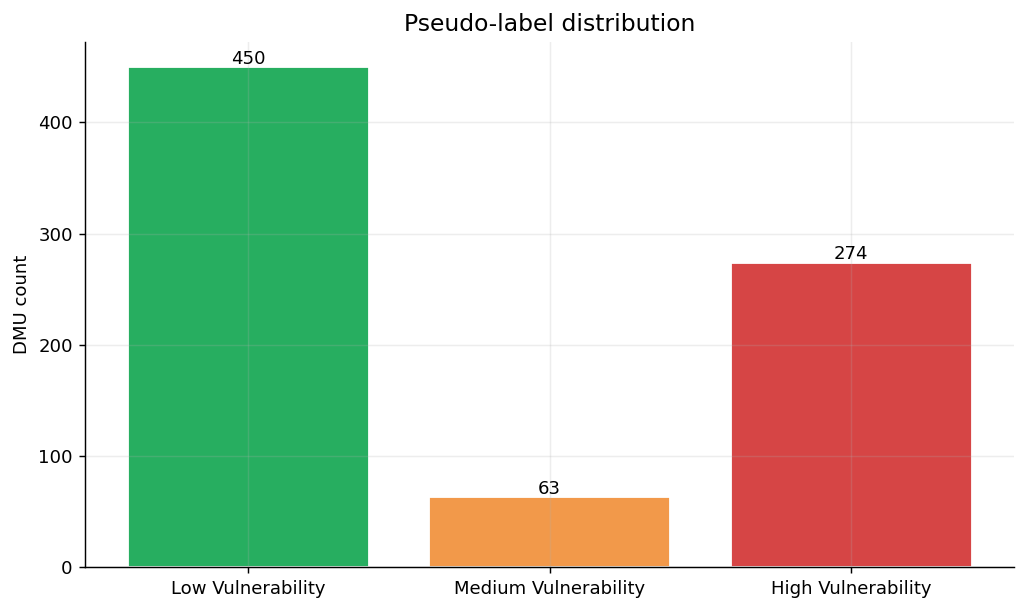

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_actor_region_vulnerability_heatmap.png


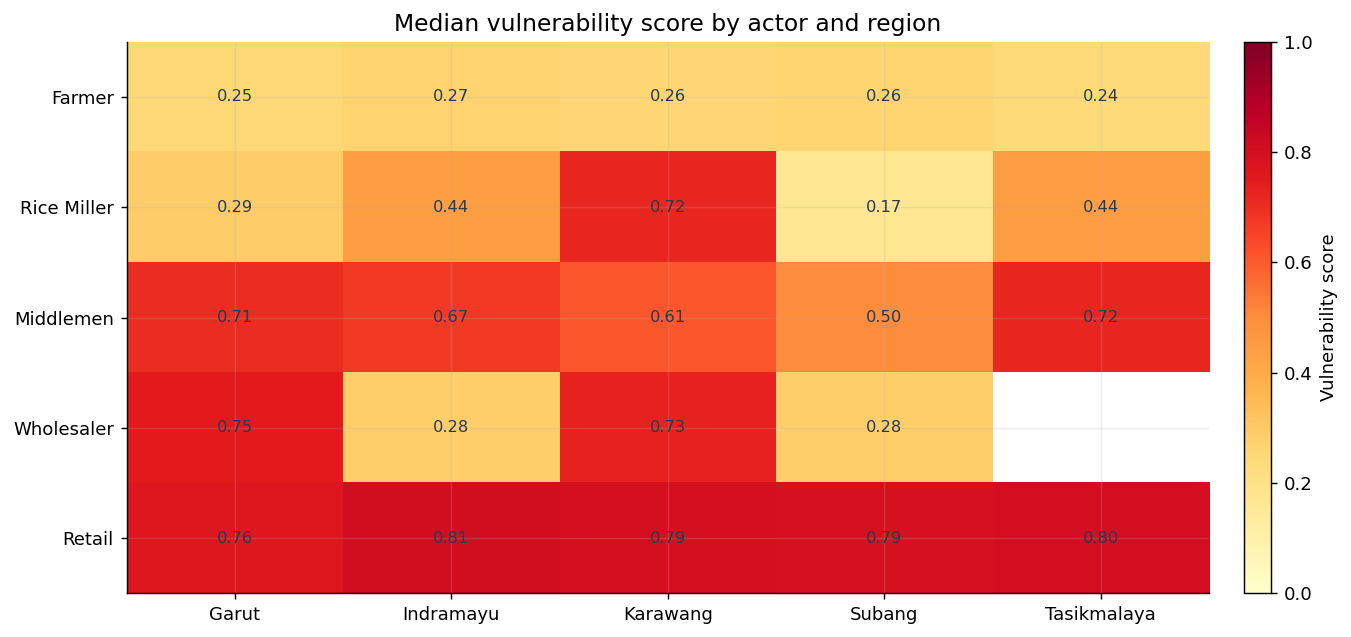

In [18]:
LABEL_ORDER=['Low Vulnerability','Medium Vulnerability','High Vulnerability']; counts=rice_feat['vulnerability_label'].value_counts().reindex(LABEL_ORDER)
fig,ax=plt.subplots(figsize=(8,4.8)); bars=ax.bar(counts.index,counts.values,color=[COLORS['green'],COLORS['orange'],COLORS['red']],edgecolor='white'); ax.set_title('Pseudo-label distribution'); ax.set_ylabel('DMU count')
for b,v in zip(bars,counts.values): ax.text(b.get_x()+b.get_width()/2,v+3,int(v),ha='center')
savefig('02_rice_vulnerability_label_distribution.png'); plt.show()
actor_region=rice_feat.groupby(['actor','region'],as_index=False).agg(n=('dmu','count'),median_vulnerability_score=('final_vulnerability_score','median'),mean_vulnerability_score=('final_vulnerability_score','mean'),high_vulnerability_share=('vulnerability_label',lambda s:np.mean(s=='High Vulnerability')*100),median_rc=('rc_ratio','median'),negative_margin_share=('negative_margin_flag',lambda s:np.mean(s)*100))
actors=[a for a in ACTOR_CONFIG if a in actor_region['actor'].unique()]; heat=actor_region.pivot(index='actor',columns='region',values='median_vulnerability_score').reindex(actors)
fig,ax=plt.subplots(figsize=(10.5,5)); im=ax.imshow(heat.values,aspect='auto',cmap='YlOrRd',vmin=0,vmax=1); ax.set_xticks(np.arange(heat.shape[1])); ax.set_xticklabels(heat.columns); ax.set_yticks(np.arange(heat.shape[0])); ax.set_yticklabels(heat.index); ax.set_title('Median vulnerability score by actor and region')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if pd.notna(heat.iloc[i,j]): ax.text(j,i,f'{heat.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9,color=COLORS['navy'])
plt.colorbar(im,ax=ax,fraction=.035,pad=.03).set_label('Vulnerability score'); savefig('02_actor_region_vulnerability_heatmap.png'); plt.show()

## 7B. Business-question answer: top vulnerable actor-region units

Method 3 should not only produce labels; it should also answer the stakeholder question directly:

> **Which actor-region units are financially and operationally vulnerable, and why?**

The next cells summarize high-vulnerability concentration, median cost/revenue pressure, and the dominant labeling reason. These outputs are designed for interpretation and downstream decision support.

,region,actor,n_units,high_vulnerability_share,medium_or_high_share,median_cost_revenue_ratio,median_margin,median_operational_burden,median_vulnerability_score,dominant_vulnerability_label,dominant_label_source,dominant_label_reason
7,Indramayu,Retail,16,1.000000,1.000000,2.114500,-3.051000e+06,1.273333,0.808179,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin; Hi...
12,Karawang,Retail,16,1.000000,1.000000,2.023333,-3.070000e+06,1.133333,0.794499,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
22,Tasikmalaya,Retail,28,1.000000,1.000000,2.017917,-3.053750e+06,1.133333,0.801855,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
17,Subang,Retail,19,0.947368,1.000000,1.733333,-2.495000e+06,1.083333,0.791776,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin; Hi...
1,Garut,Middlemen,24,0.916667,1.000000,1.357774,-6.500000e+06,0.278229,0.705973,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
2,Garut,Retail,23,0.913043,1.000000,1.742857,-2.600000e+06,1.000000,0.763876,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
21,Tasikmalaya,Middlemen,29,0.793103,1.000000,1.296086,-7.685347e+06,0.205081,0.721725,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
4,Garut,Wholesaler,25,0.720000,0.880000,1.079545,-7.000000e+06,0.152222,0.746619,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin; Fa...
13,Karawang,Rice Miller,14,0.714286,1.000000,1.064403,-5.688835e+06,0.099141,0.722032,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin
14,Karawang,Wholesaler,14,0.571429,0.785714,1.018028,-3.500000e+06,0.068838,0.726972,High Vulnerability,hard_rule_below_break_even,R/C < 1: below break-even; Negative margin; Fa...


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_top_vulnerable_actor_region.png


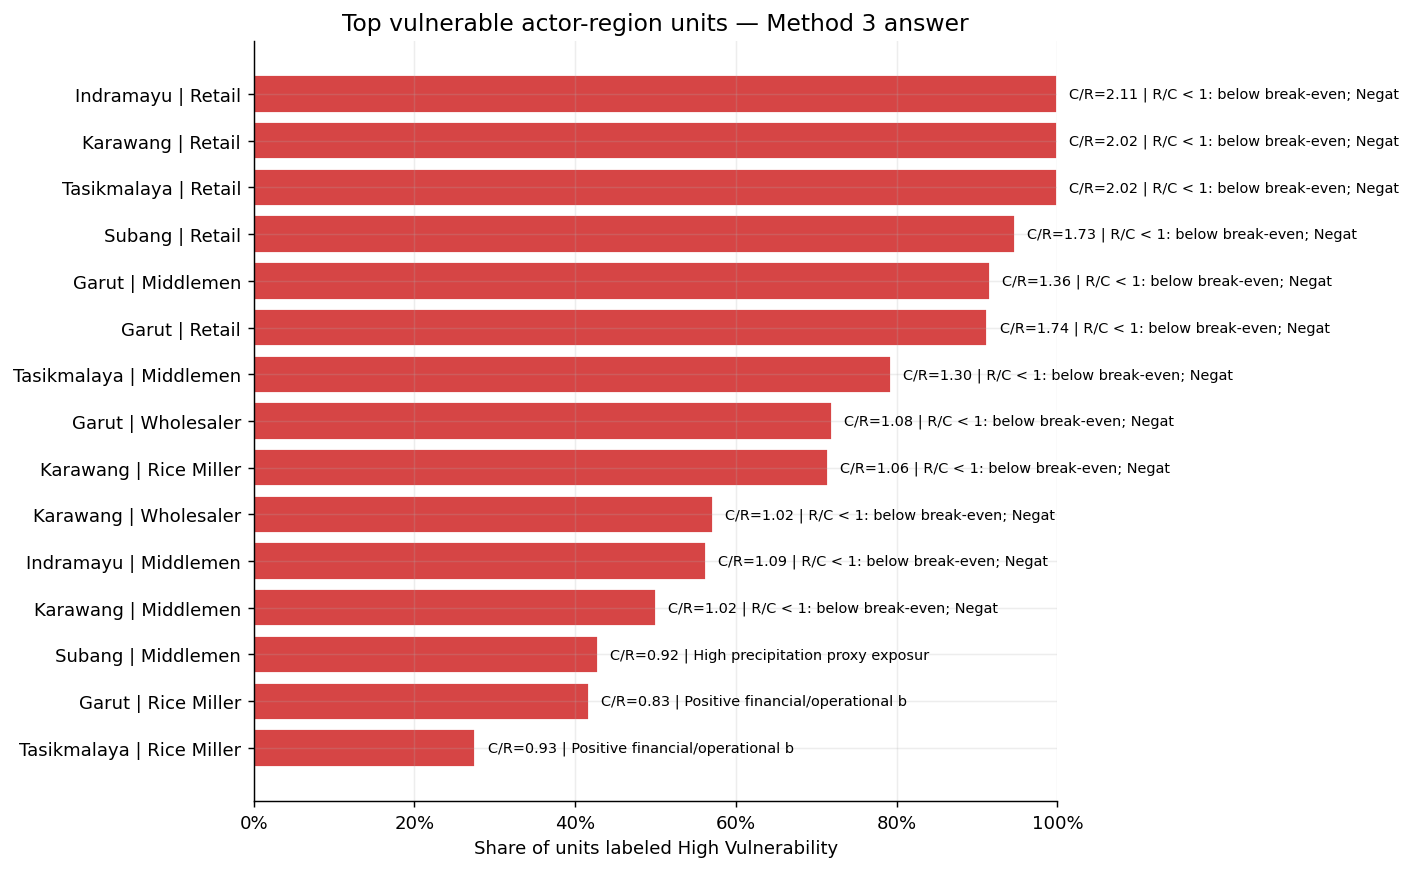

In [19]:
# Business answer table: top vulnerable actor-region units.
reason_mode = lambda s: s.dropna().value_counts().idxmax() if len(s.dropna()) else 'Unknown'

actor_region_vulnerability_answer = (
    rice_feat.assign(
        high_vulnerability_flag=rice_feat['vulnerability_label'].eq('High Vulnerability').astype(float),
        medium_or_high_flag=rice_feat['vulnerability_label'].isin(['Medium Vulnerability', 'High Vulnerability']).astype(float)
    )
    .groupby(['region', 'actor'], dropna=False)
    .agg(
        n_units=('actor', 'size'),
        high_vulnerability_share=('high_vulnerability_flag', 'mean'),
        medium_or_high_share=('medium_or_high_flag', 'mean'),
        median_cost_revenue_ratio=('cost_revenue_ratio', 'median'),
        median_margin=('margin', 'median'),
        median_operational_burden=('operational_burden_ratio', 'median'),
        median_vulnerability_score=('final_vulnerability_score', 'median'),
        dominant_vulnerability_label=('vulnerability_label', reason_mode),
        dominant_label_source=('label_source', reason_mode),
        dominant_label_reason=('label_reason', reason_mode)
    )
    .reset_index()
    .sort_values(['high_vulnerability_share', 'median_cost_revenue_ratio', 'median_vulnerability_score'], ascending=[False, False, False])
)

actor_region_vulnerability_answer.to_csv(OUTPUT_DIR / '02_top_vulnerable_actor_region.csv', index=False)
display(actor_region_vulnerability_answer.head(15))

# Visual: top actor-region high-vulnerability concentration.
top = actor_region_vulnerability_answer.head(15).copy()
fig, ax = plt.subplots(figsize=(11, 6.8))
labels = top['region'] + ' | ' + top['actor']
bars = ax.barh(labels[::-1], top['high_vulnerability_share'][::-1], color=COLORS['red'], edgecolor='white')
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Share of units labeled High Vulnerability')
ax.set_title('Top vulnerable actor-region units — Method 3 answer')
for b, cr, reason in zip(bars, top['median_cost_revenue_ratio'][::-1], top['dominant_label_reason'][::-1]):
    ax.text(b.get_width() + 0.015, b.get_y() + b.get_height()/2, f'C/R={cr:.2f} | {str(reason)[:32]}', va='center', fontsize=8)
savefig('02_top_vulnerable_actor_region.png')
plt.show()

## 7C. Label-source and rule-contribution audit

Because the target is a pseudo-label, the notebook must show **why** labels were assigned. These diagnostics expose whether vulnerability is mostly driven by break-even failure, negative margin, thin buffer, composite pressure, or other domain rules.

,vulnerability_label,label_source,n_units,share_within_label
0,High Vulnerability,hard_rule_below_break_even,270,0.985401
1,High Vulnerability,soft_rule_high_composite_pressure,4,0.014599
2,Low Vulnerability,default_positive_buffer,450,1.000000
4,Medium Vulnerability,soft_rule_thin_financial_buffer,62,0.984127
3,Medium Vulnerability,soft_rule_medium_composite_pressure,1,0.015873


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_label_source_distribution.png


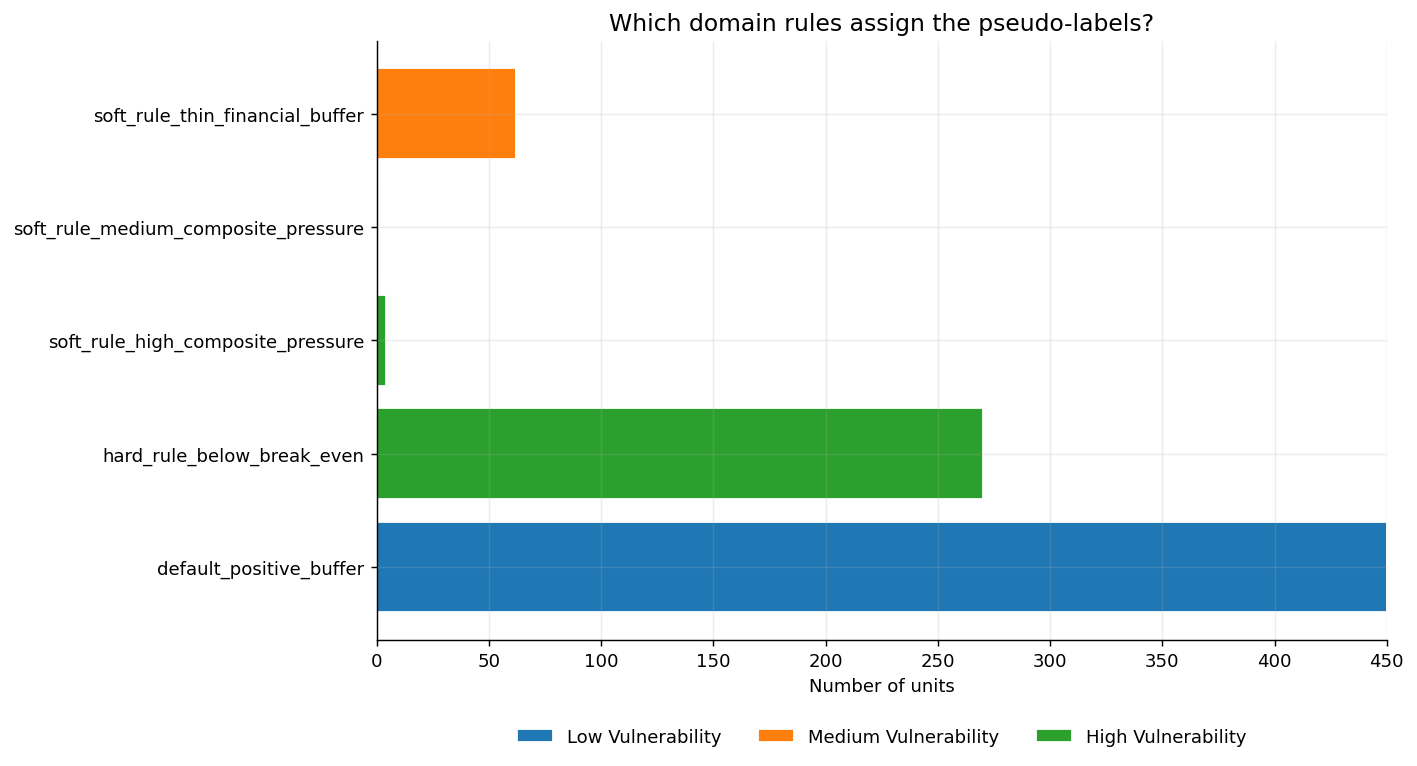

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_rule_contribution_by_actor.png


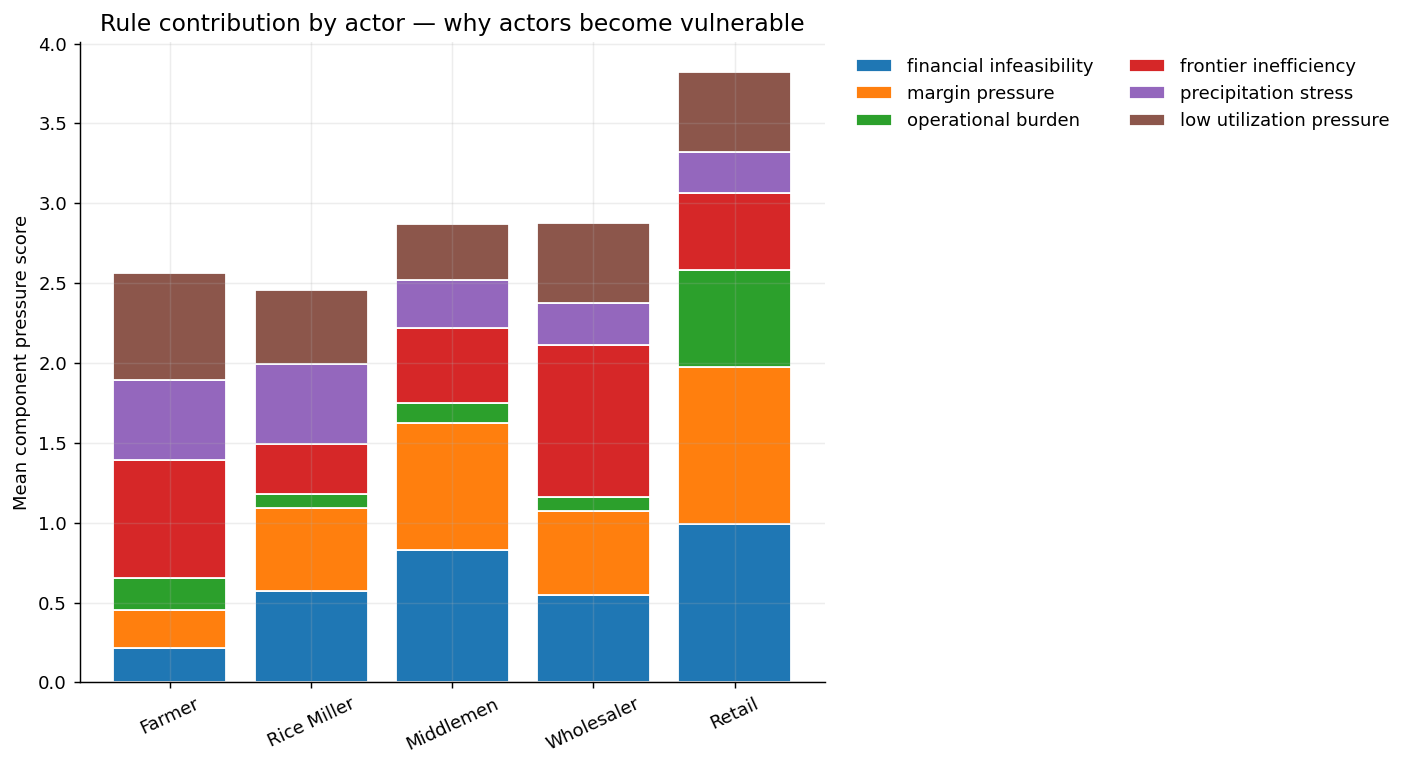

In [20]:
# Label-source distribution.
label_source_dist = (
    rice_feat.groupby(['vulnerability_label', 'label_source'], dropna=False)
    .size()
    .reset_index(name='n_units')
)
label_source_dist['share_within_label'] = label_source_dist.groupby('vulnerability_label')['n_units'].transform(lambda x: x / x.sum())
label_source_dist.to_csv(OUTPUT_DIR / '02_label_source_distribution.csv', index=False)
display(label_source_dist.sort_values(['vulnerability_label', 'n_units'], ascending=[True, False]))

# Plot label source distribution for High/Medium/Low.
pivot = label_source_dist.pivot(index='label_source', columns='vulnerability_label', values='n_units').fillna(0)
pivot = pivot.reindex(columns=[c for c in LABEL_ORDER if c in pivot.columns])
fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    vals = pivot[col].values
    ax.barh(pivot.index, vals, left=bottom, label=col, edgecolor='white')
    bottom += vals
ax.set_xlabel('Number of units')
ax.set_title('Which domain rules assign the pseudo-labels?')
ax.legend(ncols=3, bbox_to_anchor=(0.5, -0.12), loc='upper center')
savefig('02_label_source_distribution.png')
plt.show()

# Rule contribution by actor.
rule_components = [c for c in RULE_WEIGHTS if c in rice_feat.columns]
actor_rule_contrib = rice_feat.groupby('actor')[rule_components].mean().reindex([a for a in ACTOR_CONFIG if a in rice_feat['actor'].unique()])
actor_rule_contrib.to_csv(OUTPUT_DIR / '02_rule_contribution_by_actor.csv')

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(actor_rule_contrib))
for col in rule_components:
    vals = actor_rule_contrib[col].fillna(0).values
    ax.bar(actor_rule_contrib.index, vals, bottom=bottom, label=col.replace('_score', '').replace('_', ' '), edgecolor='white')
    bottom += vals
ax.set_ylabel('Mean component pressure score')
ax.set_title('Rule contribution by actor — why actors become vulnerable')
ax.tick_params(axis='x', rotation=25)
ax.legend(ncols=2, bbox_to_anchor=(1.02, 1), loc='upper left')
savefig('02_rule_contribution_by_actor.png')
plt.show()

## 8. Preliminary downstream handoff: flood scenarios and vulnerability summaries

This section only prepares lightweight handoff files for later notebooks. The final hazard × vulnerability decision layer is intentionally handled in **Notebook 05**, not here.

,actor,region,n_x,median_vulnerability_score,mean_vulnerability_score,high_vulnerability_share,median_rc,negative_margin_share,flood_risk_label,n_y,mean_flood_probability,median_flood_probability,mean_pressure,hazard_score,flood_logistics_priority_score,priority_label
33,Retail,Indramayu,16,0.808179,0.801831,100.000000,0.472937,100.000000,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.266699,Moderate Priority
42,Retail,Tasikmalaya,28,0.801855,0.804336,100.000000,0.495584,100.000000,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.264612,Moderate Priority
36,Retail,Karawang,16,0.794499,0.799417,100.000000,0.494242,100.000000,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.262185,Moderate Priority
39,Retail,Subang,19,0.791776,0.783370,94.736842,0.576923,94.736842,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.261286,Moderate Priority
30,Retail,Garut,23,0.763876,0.731213,91.304348,0.573770,91.304348,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.252079,Moderate Priority
60,Wholesaler,Garut,25,0.746619,0.660357,72.000000,0.926316,72.000000,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.246384,Moderate Priority
66,Wholesaler,Karawang,14,0.726972,0.587405,57.142857,0.982291,57.142857,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.239901,Monitoring Priority
51,Rice Miller,Karawang,14,0.722032,0.665166,71.428571,0.939601,71.428571,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.238271,Monitoring Priority
27,Middlemen,Tasikmalaya,29,0.721725,0.690568,79.310345,0.771554,79.310345,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.238169,Monitoring Priority
15,Middlemen,Garut,24,0.705973,0.699414,91.666667,0.736500,91.666667,Low Flood Risk,16691,0.445517,0.45,4.455995,0.33,0.232971,Monitoring Priority


saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\02_high_flood_priority_ranking.png


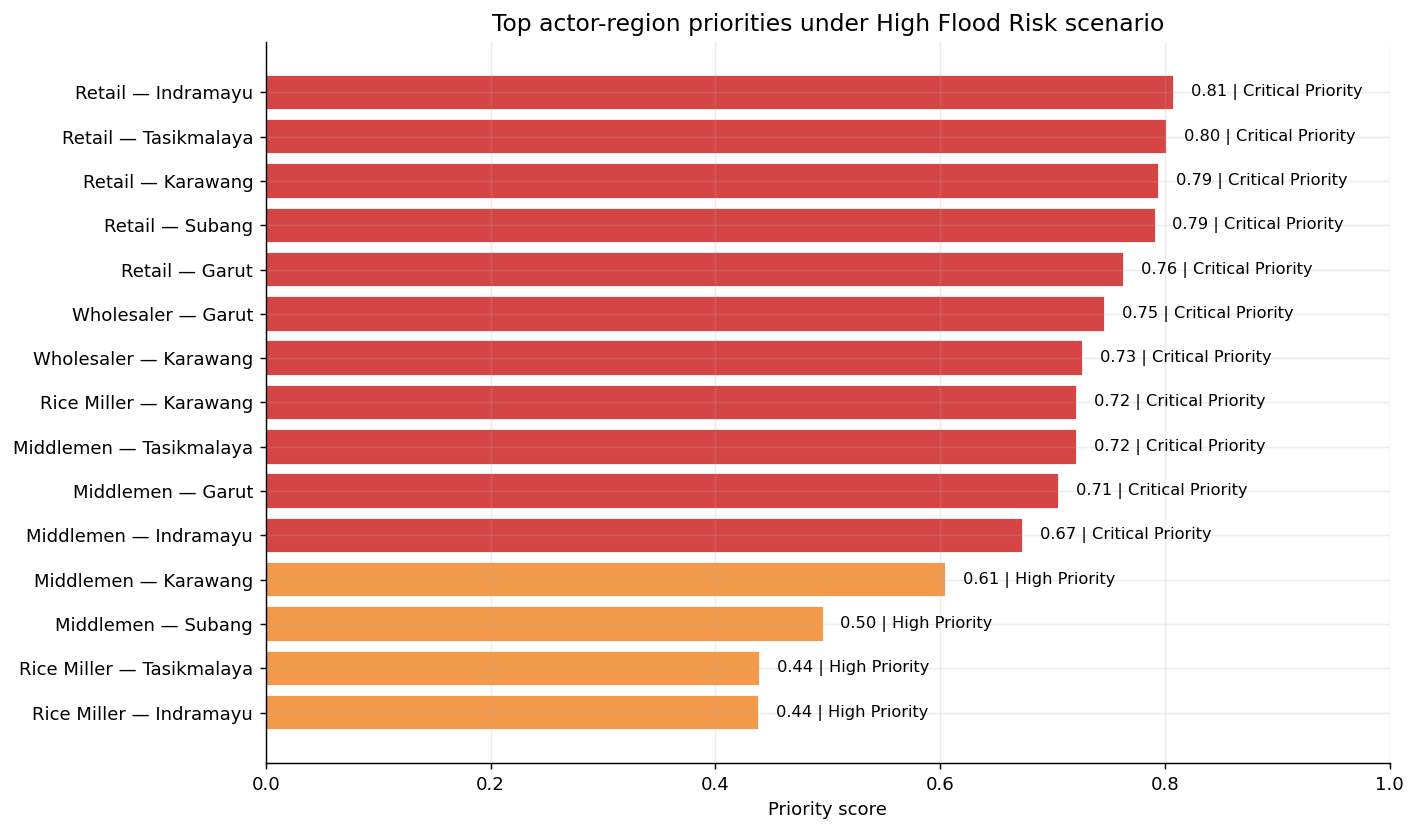

In [21]:
flood_scenarios=flood.groupby('flood_risk_label',as_index=False).agg(n=(TARGET_FLOOD,'count'),mean_flood_probability=(TARGET_FLOOD,'mean'),median_flood_probability=(TARGET_FLOOD,'median'),mean_pressure=('total_pressure_score','mean'))
order=['Low Flood Risk','Medium Flood Risk','High Flood Risk']; flood_scenarios['flood_risk_label']=pd.Categorical(flood_scenarios['flood_risk_label'],categories=order,ordered=True); flood_scenarios=flood_scenarios.sort_values('flood_risk_label'); flood_scenarios['hazard_score']=np.linspace(.33,1.0,len(flood_scenarios))
scenario=actor_region.merge(flood_scenarios,how='cross'); scenario['flood_logistics_priority_score']=(scenario['median_vulnerability_score']*scenario['hazard_score']).clip(0,1)
def prio(x): return 'Critical Priority' if x>=.62 else 'High Priority' if x>=.42 else 'Moderate Priority' if x>=.24 else 'Monitoring Priority'
scenario['priority_label']=scenario['flood_logistics_priority_score'].apply(prio); scenario=scenario.sort_values(['flood_risk_label','flood_logistics_priority_score'],ascending=[True,False])
display(scenario.head(10))
high=scenario[scenario['flood_risk_label'].eq('High Flood Risk')].copy(); high['actor_region']=high['actor']+' — '+high['region']; top=high.sort_values('flood_logistics_priority_score').tail(15)
fig,ax=plt.subplots(figsize=(11,6.5)); cmap={'Critical Priority':COLORS['red'],'High Priority':COLORS['orange'],'Moderate Priority':COLORS['blue'],'Monitoring Priority':COLORS['green']}; bars=ax.barh(top['actor_region'],top['flood_logistics_priority_score'],color=top['priority_label'].map(cmap),edgecolor='white'); ax.set_xlim(0,1); ax.set_xlabel('Priority score'); ax.set_title('Top actor-region priorities under High Flood Risk scenario')
for b,s,l in zip(bars,top['flood_logistics_priority_score'],top['priority_label']): ax.text(s+.015,b.get_y()+b.get_height()/2,f'{s:.2f} | {l}',va='center',fontsize=9)
savefig('02_high_flood_priority_ranking.png'); plt.show()

## 9. Save Notebook 02 outputs

In [22]:

AUDIT_ONLY_COLUMNS = [
    'vulnerability_cluster',
    'cluster_support_score',
    'cluster_support_label',
    'rule_cluster_agreement',
    'cluster_support_gap',
]

LABEL_CONSTRUCTION_COLUMNS = [
    'final_vulnerability_score',
    'rule_vulnerability_score',
    *list(RULE_WEIGHTS.keys()),
    'below_break_even_flag',
    'negative_margin_flag',
    'label_reason',
    'label_source',
    'labeling_function_hits',
    *LF_COLUMNS,
]

# Keep only one of the inverse feasibility ratios in the operational model to avoid redundant importance.
# cost_revenue_ratio is retained because it is easier to interpret for vulnerability: cost > revenue => risk.
REDUNDANT_OPERATIONAL_EXCLUDE = ['rc_ratio']
ADMIN_COLUMNS = ['source_sheet', 'source_row', 'actor_role']

front = [
    'actor','region','dmu','actor_role','vulnerability_label','final_vulnerability_score',
    'label_source','labeling_function_hits','label_reason',
    'total_cost','output_value','margin','rc_ratio','cost_revenue_ratio','operational_burden_ratio',
    'precipitation_stress_raw','rule_vulnerability_score','cluster_support_score','cluster_support_label',
    'rule_cluster_agreement','cluster_support_gap','vulnerability_cluster',
    *LF_COLUMNS,
]
rice_out = rice_feat[[c for c in front if c in rice_feat.columns] + [c for c in rice_feat.columns if c not in front]]

feature_policy = []
for c in rice_out.columns:
    if c == 'vulnerability_label':
        status = 'target'
    elif c in AUDIT_ONLY_COLUMNS:
        status = 'audit_only_excluded_from_modeling'
    elif c in LABEL_CONSTRUCTION_COLUMNS:
        status = 'label_construction_excluded_from_operational'
    elif c in REDUNDANT_OPERATIONAL_EXCLUDE:
        status = 'redundant_inverse_excluded_from_operational'
    elif c in ADMIN_COLUMNS or c in ['dmu']:
        status = 'identifier_or_admin_excluded_from_modeling'
    else:
        status = 'operational_candidate'
    feature_policy.append({'column': c, 'modeling_policy': status})
feature_policy = pd.DataFrame(feature_policy)

flood.to_csv(OUTPUT_DIR/'02_flood_modeling_dataset.csv', index=False)
rice_out.to_csv(OUTPUT_DIR/'02_rice_vulnerability_dataset.csv', index=False)
actor_region.to_csv(OUTPUT_DIR/'02_actor_region_vulnerability.csv', index=False)
flood_scenarios.to_csv(OUTPUT_DIR/'02_flood_scenarios.csv', index=False)
scenario.to_csv(OUTPUT_DIR/'02_decision_support_matrix.csv', index=False)
cluster_profile.to_csv(OUTPUT_DIR/'02_cluster_profile.csv', index=False)
silhouette_report.to_csv(OUTPUT_DIR/'02_cluster_silhouette_report.csv', index=False)
rule_summary.to_csv(OUTPUT_DIR/'02_rule_weight_reference_summary.csv', index=False)
labeling_functions.to_csv(OUTPUT_DIR/'02_method3_labeling_functions.csv', index=False)
threshold_policy.to_csv(OUTPUT_DIR/'02_method3_threshold_policy.csv', index=False)
label_source_report.to_csv(OUTPUT_DIR/'02_method3_label_source_report.csv', index=False)
audit.to_csv(OUTPUT_DIR/'02_data_quality_report.csv', index=False)
feature_policy.to_csv(OUTPUT_DIR/'02_feature_modeling_policy.csv', index=False)

label_report = (
    rice_out.groupby('vulnerability_label', as_index=False)
    .agg(
        n=('dmu','count'),
        mean_score=('final_vulnerability_score','mean'),
        median_rc=('rc_ratio','median'),
        median_cost_revenue_ratio=('cost_revenue_ratio', 'median'),
        negative_margin_share=('negative_margin_flag', lambda s: np.mean(s) * 100),
        hard_rule_share=('label_source', lambda s: s.str.startswith('hard_rule').mean() * 100),
        cluster_agreement_share=('rule_cluster_agreement', lambda s: np.mean(s) * 100),
    )
)
label_report['vulnerability_label'] = pd.Categorical(label_report['vulnerability_label'], categories=LABEL_ORDER, ordered=True)
label_report = label_report.sort_values('vulnerability_label')
label_report.to_csv(OUTPUT_DIR/'02_labeling_report.csv', index=False)

methodological_notes = f"""# Notebook 02 Methodological Notes — Method 3

## Labeling stance

The rice supply chain dataset has no externally validated target label for vulnerability. Therefore, this notebook uses **Method 3: paper-grounded weak labeling**. Domain rules create transparent pseudo labels, while clustering is used only as support/audit.

## Literature-grounded rules

1. **Weak supervision** — Ratner et al. (2017) justify using rule-based labeling functions when hand labels are unavailable.
2. **DEA / DMU efficiency** — Charnes, Cooper, and Rhodes (1978) and Banker, Charnes, and Cooper (1984) motivate relative efficiency benchmarking among comparable decision-making units. This notebook implements a lightweight actor-wise frontier proxy, not exact LP DEA.
3. **R/C feasibility** — agricultural project / farm feasibility logic treats revenue lower than cost as financially infeasible. Therefore `R/C < 1` is a hard high-vulnerability rule.
4. **Margin health** — negative or thin margin indicates low buffer against disruption.
5. **Operational burden** — high operating cost relative to output weakens the ability to absorb shocks.
6. **Supply chain resilience** — resilience literature emphasizes persistence/adaptation under disruptions, so financially and operationally weak nodes are treated as less resilient under flood-related stress.
7. **Cluster support** — Rousseeuw (1987) motivates silhouette-based cluster validation. Here clustering audits structure only and does not define the target.

## Rule weights

{rule_summary.to_markdown(index=False)}

## Labeling functions

{labeling_functions.to_markdown(index=False)}

## Label thresholds

{threshold_policy.to_markdown(index=False)}

The score thresholds are internal calibrated decision thresholds. They are not claimed as universal constants from prior literature. Hard financial conditions such as `R/C < 1` and negative margin dominate before soft composite thresholds are used.

## Cluster leakage prevention

Cluster outputs are kept only for audit and interpretability. The following columns are marked as audit-only and must be excluded from the operational model in Notebook 03:

{pd.Series(AUDIT_ONLY_COLUMNS).to_markdown(index=False)}

## Operational feature policy

`rc_ratio` is marked as redundant and excluded from the operational model because `cost_revenue_ratio` carries the inverse information and is easier to interpret for vulnerability: cost greater than revenue indicates financial pressure.

## Data policy

External papers are used only for methodological justification. No external dataset, labels, prices, maps, rainfall records, or region-level disaster observations are used for training.
"""
(OUTPUT_DIR/'02_methodological_notes.md').write_text(methodological_notes, encoding='utf-8')

metadata = {
    'method_name': 'Method 3 - Paper-grounded weak labeling',
    'target_flood': TARGET_FLOOD,
    'flood_features': [c for c in flood_features],
    'rice_target': 'vulnerability_label',
    'label_order': LABEL_ORDER,
    'rule_weights': RULE_WEIGHTS,
    'rule_component_columns': list(RULE_WEIGHTS.keys()),
    'labeling_function_columns': LF_COLUMNS,
    'audit_only_columns': AUDIT_ONLY_COLUMNS,
    'label_construction_columns': LABEL_CONSTRUCTION_COLUMNS,
    'redundant_operational_exclude_columns': REDUNDANT_OPERATIONAL_EXCLUDE,
    'admin_columns': ADMIN_COLUMNS,
    'domain_references': DOMAIN_REFERENCES,
    'labeling_policy': 'Rule-based weak supervision is primary; clustering is support/audit only.',
    'operational_model_policy': 'Notebook 03 must exclude cluster outputs, rule scores, final scores, hard rule flags, labeling function outputs, labels, redundant inverse ratios, and admin identifiers from operational_prediction.',
    'thresholds': {
        'break_even_rc': BREAK_EVEN_RC,
        'thin_rc_buffer': THIN_RC_BUFFER,
        'thin_margin_ratio': THIN_MARGIN_RATIO,
        'high_score_threshold': HIGH_SCORE_THRESHOLD,
        'medium_score_threshold': MEDIUM_SCORE_THRESHOLD,
        'high_vulnerability': 'R/C < 1, margin < 0, or rule score >= 0.62',
        'medium_vulnerability': 'R/C < 1.15, margin_ratio < 0.10, or rule score >= 0.40',
        'low_vulnerability': 'otherwise'
    },
    'selected_cluster_k': int(selected_k),
    'best_silhouette': float(silhouette_report.iloc[0]['silhouette']),
    'cluster_agreement_rate': float(rice_feat['rule_cluster_agreement'].mean()),
    'integration_note': 'Scenario-based integration only; no row-wise merge.'
}
json.dump(metadata, open(OUTPUT_DIR/'02_preprocessing_metadata.json', 'w'), indent=2)

print('Saved:', sorted(p.name for p in OUTPUT_DIR.glob('02_*')))
display(feature_policy['modeling_policy'].value_counts().rename_axis('policy').reset_index(name='n_columns'))


Saved: ['02_actor_region_vulnerability.csv', '02_cluster_profile.csv', '02_cluster_silhouette_report.csv', '02_data_quality_report.csv', '02_decision_support_matrix.csv', '02_feature_modeling_policy.csv', '02_flood_modeling_dataset.csv', '02_flood_scenarios.csv', '02_label_source_distribution.csv', '02_labeling_report.csv', '02_method3_label_source_report.csv', '02_method3_labeling_functions.csv', '02_method3_threshold_policy.csv', '02_methodological_notes.md', '02_preprocessing_metadata.json', '02_rice_vulnerability_dataset.csv', '02_rule_contribution_by_actor.csv', '02_rule_weight_reference_summary.csv', '02_top_vulnerable_actor_region.csv']


,policy,n_columns
0,operational_candidate,35
1,label_construction_excluded_from_operational,19
2,audit_only_excluded_from_modeling,5
3,identifier_or_admin_excluded_from_modeling,4
4,target,1
5,redundant_inverse_excluded_from_operational,1
